# RAG Inspector: when keyword, when vector, when hybrid, and why ANN 🕵️

## Your mission
You are the **retrieval engineers** for the RAG assistant that powers this very course.
Students keep complaining:

> "I ask the course bot a question and it gives me an answer that has nothing to do with what I asked."

Something in the retrieval layer is suboptimal, and your job is to fix this so that all questions can be answered correctly.

You will work through four parts:

| Part | What you do | What you learn |
|-----|-------------|----------------|
| 1 | The bot only does keyword search. Watch it fail. | where keyword search breaks |
| 2 | Add vector search | where meaning beats words |
| 3 | Fuse them into hybrid, then measure everything | why robust beats specialist |
| 4 | Scale to many vectors with ANN | the speed vs recall tradeoff |
| 5 | Watch your RAG in action | how much you have accomplished |


In [ ]:
import os, sys

REPO_OWNER = "eth-fdd-fs26"
REPO_NAME  = "FDD-WE5-public"

def _in_colab():
    try:
        import google.colab
        return True
    except Exception:
        return False

if _in_colab():
    url = f"https://github.com/{REPO_OWNER}/{REPO_NAME}.git"
    if not os.path.isdir(REPO_NAME):
        print("Cloning the exercise repo…")
        !git clone -q "$url"
    else:                                 # already cloned earlier — refresh to the latest version
        print("Updating the exercise repo to the latest version…")
        !git -C "$REPO_NAME" pull -q "$url" || echo "  (could not pull — using the existing copy)"
    os.chdir('./FDD-WE5-public/exercises')

In [ ]:
#@title Setup: install and import everything (run me)
!pip install -q rank_bm25 hnswlib sentence-transformers pandas pyarrow matplotlib google-genai

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
import hnswlib
from rank_bm25 import BM25Okapi
from google import genai
from IPython.display import display, HTML
import ipywidgets as widgets
from datasets import load_dataset
import re
import pickle
print("all libraries installed and imported")


/opt/homebrew/Caskroom/miniconda/base/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'dlopen(/opt/homebrew/Caskroom/miniconda/base/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <BD0BF3A8-D5AB-3800-B76D-0E8456DB6589> /opt/homebrew/Caskroom/miniconda/base/lib/python3.11/site-packages/torchvision/image.so
  Expected in:     <25C510F7-7AEE-3D64-80ED-95874DC6BECD> /opt/homebrew/Caskroom/miniconda/base/lib/python3.11/site-packages/torch/lib/libtorch_cpu.dylib'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


all libraries installed and imported


In [ ]:
# @title Visualization: Detailed RAG Architecture Flow {display-mode: "form"}
display(
    HTML(r"""
<div style="text-align:center;margin:16px 0;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif">
<svg viewBox="0 0 920 300" width="100%" style="max-width:920px;background:#f8f9fa;border-radius:12px;border:1px solid #e9ecef;padding:16px;box-sizing:border-box">
  <defs>
    <!-- Shadow filter for card depth -->
    <filter id="shadow" x="-5%" y="-5%" width="110%" height="110%">
      <feDropShadow dx="0" dy="1" stdDeviation="2" flood-color="#000000" flood-opacity="0.04"/>
    </filter>

    <!-- Arrowhead markers -->
    <marker id="arrow-gray" markerWidth="8" markerHeight="8" refX="6" refY="4" orient="auto">
      <path d="M0,0 L8,4 L0,8 z" fill="#8c8c8c"/>
    </marker>
    <marker id="arrow-green" markerWidth="8" markerHeight="8" refX="6" refY="4" orient="auto">
      <path d="M0,0 L8,4 L0,8 z" fill="#389e0d"/>
    </marker>
  </defs>

  <style>
    .card { fill: #ffffff; stroke: #e0e0e0; stroke-width: 1; rx: 8px; filter: url(#shadow); }
    .title-box { font: 700 13px -apple-system,BlinkMacSystemFont,sans-serif; fill: #1f1f1f; }
    .badge-text { font: 700 9px -apple-system,BlinkMacSystemFont,sans-serif; letter-spacing: 0.5px; }
    .desc-text { font: 400 11px -apple-system,BlinkMacSystemFont,sans-serif; fill: #595959; }
    .code-text { font: 500 10px SFMono-Regular,Consolas,monospace; fill: #262626; }
    .arrow { stroke: #8c8c8c; stroke-width: 2; marker-end: url(#arrow-gray); }
    .arrow-gen { stroke: #389e0d; stroke-dasharray: 4,4; stroke-width: 2; marker-end: url(#arrow-green); }
  </style>

  <!-- 1. Diagram Title Banner (Replaced System Instruction) -->
  <rect x="20" y="10" width="880" height="42" rx="6" fill="#ffffff" stroke="#e0e0e0" stroke-width="1"/>
  <rect x="20" y="10" width="5" height="42" rx="2" fill="#389e0d"/>
  <text class="badge-text" x="35" y="27" fill="#389e0d">RAG PIPELINE ARCHITECTURE</text>
  <text style="font: 600 13px -apple-system,BlinkMacSystemFont,sans-serif; fill: #1f1f1f;" x="35" y="42">End-to-End Retrieval Augmented Generation Workflow</text>

  <!-- Flow Connectors (Lines) -->
  <line class="arrow" x1="200" y1="180" x2="230" y2="180"/>
  <line class="arrow" x1="420" y1="180" x2="450" y2="180"/>
  <line class="arrow-gen" x1="640" y1="180" x2="670" y2="180"/>

  <!-- Step 1: User Question -->
  <g transform="translate(20, 70)">
    <rect class="card" x="0" y="0" width="180" height="205"/>
    <rect x="12" y="12" width="70" height="18" rx="4" fill="#e6f4ff"/>
    <text class="badge-text" x="18" y="24" fill="#0958d9">INPUT QUERY</text>
    <text class="title-box" x="12" y="52">User Question</text>
    <text class="desc-text" x="12" y="70">Raw user request</text>
    <text class="desc-text" x="12" y="86">submitted to system</text>

    <rect x="12" y="105" width="156" height="88" rx="6" fill="#fafafa" stroke="#f0f0f0"/>
    <text class="code-text" x="20" y="130">q = "What is BERT?"</text>
  </g>

  <!-- Step 2: Context Retrieval -->
  <g transform="translate(240, 70)">
    <rect class="card" x="0" y="0" width="180" height="205"/>
    <rect x="12" y="12" width="110" height="18" rx="4" fill="#f6ffed"/>
    <text class="badge-text" x="18" y="24" fill="#389e0d">RETRIEVAL ENGINE</text>
    <text class="title-box" x="12" y="52">Context Search</text>
    <text class="desc-text" x="12" y="70">Fetch Top-K relevant</text>
    <text class="desc-text" x="12" y="86">knowledge chunks</text>

    <rect x="12" y="105" width="156" height="88" rx="6" fill="#fafafa" stroke="#f0f0f0"/>
    <text class="code-text" x="20" y="128">• Keyword (BM25)</text>
    <text class="code-text" x="20" y="150">• Vector (Cosine)</text>
    <text class="code-text" x="20" y="172">• Hybrid (RRF)</text>
  </g>

  <!-- Step 3: Prompt Augmentation -->
  <g transform="translate(460, 70)">
    <rect class="card" x="0" y="0" width="180" height="205"/>
    <rect x="12" y="12" width="125" height="18" rx="4" fill="#f9f0ff"/>
    <text class="badge-text" x="18" y="24" fill="#531dab">PROMPT AUGMENTATION</text>
    <text class="title-box" x="12" y="52">Construct Prompt</text>
    <text class="desc-text" x="12" y="70">Assemble question</text>
    <text class="desc-text" x="12" y="86">followed by chunks</text>

    <rect x="12" y="105" width="156" height="88" rx="6" fill="#fdfaff" stroke="#f0e6ff"/>
    <!-- Swapped Order: Question first, then Context -->
    <text class="code-text" x="20" y="130" fill="#391085">Question: {q}</text>
    <text class="code-text" x="20" y="152" fill="#391085">Context: [1]...</text>
  </g>

  <!-- Step 4: LLM Generation -->
  <g transform="translate(680, 70)">
    <rect class="card" x="0" y="0" width="220" height="205" stroke="#b7eb8f" style="fill:#f6ffed"/>
    <rect x="12" y="12" width="105" height="18" rx="4" fill="#d9f7be"/>
    <text class="badge-text" x="18" y="24" fill="#135200">LLM GENERATION</text>
    <text class="title-box" x="12" y="52">Grounding Check</text>
    <text class="desc-text" x="12" y="70" fill="#274683">Verifies factual output</text>
    <text class="desc-text" x="12" y="86" fill="#274683">against context boundaries</text>

    <rect x="12" y="105" width="196" height="88" rx="6" fill="#ffffff" stroke="#b7eb8f"/>
    <text class="code-text" x="20" y="130" fill="#135200">Grounded: "BERT is..."</text>
    <text class="code-text" x="20" y="152" fill="#8c8c8c">Missing: "I don't know"</text>
  </g>
</svg>
</div>
"""
    )
)

## The course references 📂: from the ML-ArXiv-Papers Dataset
This course is covering such a wide range of topics that it's not unreasonable to resort to a large ML paper dataset as the knowledge base.
We will use the CShorten/ML-ArXiv-Papers dataset from Huggingface and apply a simple chunking and embedding workflow.

Each paper has an ArXiv ID, a title and an abstract. We apply chunking to the abstracts and embed those chunks only. The chunks are stored in a dataframe named `chunk`.



In [ ]:
EMB_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2" # sentence-transformer model for embedding the text
N_ARXIV = 5000 # number of arxiv papers to sample for the dataset
SEED = 42 # sampling dataset
ALL_KS = [1, 2, 5, 10, 15,  50, 100, 200, 300] # all the k values to evaluate for recall@k

In [ ]:
# @title Helper functions
def clean(s):
    return re.sub(r"\s+", " ", str(s)).strip()
def word_chunk(text, size=90, overlap=20):
    '''Chunks a string into overlapping sliding windows of a given size.'''
    words = text.split()
    if len(words) <= size:
        return [text]
    chunks, start = [], 0
    while start < len(words):
        chunks.append(" ".join(words[start:start + size]))
        start += size - overlap
    return chunks

In [ ]:
#@title Load Dataset and Prepare Chunks
ds = load_dataset("CShorten/ML-ArXiv-Papers", split="train")
df = ds.to_pandas()
df = df.rename(columns={c: c.lower() for c in df.columns})
tcol = "title" if "title" in df.columns else df.columns[0]
acol = "abstract" if "abstract" in df.columns else df.columns[-1]
df = df[[tcol, acol]].dropna()
df["title"] = df[tcol].map(clean)
df["abstract"] = df[acol].map(clean)
df = df[df["abstract"].str.split().str.len() >= 20]
df = df.sample(n=min(N_ARXIV, len(df)), random_state=SEED).reset_index(drop=True)
rows = [{"doc_id": f"arxiv_{i}", "title": r["title"], "text": r["abstract"], "is_gold": False}
        for i, r in df.iterrows()]

docs = pd.DataFrame(rows)
chunk_rows = []
for _, r in docs.iterrows():
    for j, ch in enumerate(word_chunk(r["text"])):
        chunk_rows.append({"chunk_id": f"{r['doc_id']}::c{j}", "doc_id": r["doc_id"],
                            "title": r["title"], "text": ch, "is_gold": r["is_gold"]})
chunks = pd.DataFrame(chunk_rows)

In [ ]:
#@title Define sample queries and their corresponding source documents
# KEYWORD: queries better suited for exact term matching (keyword search)
KEYWORD_GOLD = {
    'arxiv_34::c0': 'Explain the SPEVI+ algorithm for reinforcement learning and its novelty.',
    'arxiv_128::c0': 'Explain the connection between GFMTs and MPNNs.',
    'arxiv_280::c0': 'Tell me about the non-asymptotic guarantees of gMPNNs on OOD data.',
    'arxiv_709::c0': 'What is the G2GT transformer model?',
    'arxiv_1005::c0': 'Is Pipe-it a framework for IoT Edge intelligence aimed to increase throughput?',
    'arxiv_1398::c0': 'Explain the variant of gradient descent called Hebbian descent algorithm.',
    'arxiv_2469::c0': 'How can I use DIVA as a generative model for domain generalization?',
    'arxiv_2526::c0': 'Does GT-SAGA converge for non-convex minimization problems?',
    'arxiv_2664::c0': 'What do SIDGPs and ES stand for in deep generative models',
    'arxiv_4667::c0': 'What is the vision framework NASA used for 3D objects?',
}
# VECTOR: queries better suited for semantic matching (vector search)
VECTOR_GOLD = {
    'arxiv_39::c1': 'How can we define the importance of an object in a collection via pairwise comparison?',
    'arxiv_1089::c1': 'Can language models be trained without the softmax function in order to speed up compute?',
    'arxiv_1909::c0': 'Is there a music-generating algorithm which can correct itself to avoid the common pitfalls of autoregressive models?',
    'arxiv_2145::c0': 'How can we achieve fast and scalable learning of sparse changes in high-dimensional gaussian graphical model structures?',
    'arxiv_2213::c0': 'When measuring the transferability of adversarial attacks on NNs, are both L-infinity and L-2 norms informative measures of perturbation?',
    'arxiv_2293::c0': 'Find an evidence-based way to obtain a similarity measure for symmetric positive definite matrix representations.',
    'arxiv_2513::c0': 'Explore whether adversarial attacks on images can be done by adding signals around an image without changing the image itself.',
    'arxiv_3454::c0': 'Explain how representation learning for videos can be done to ensure that the learned features are coherent across time and change smoothly.',
    'arxiv_3618::c0': 'How can I obtain multi-scale functional representations of proteins from single-cell microscopy data?',
    'arxiv_4756::c0': 'Find the paper which employs random projection method to construct neighborhood graphs efficiently.',
}
# Set the respective chunks as "gold" (true source documents) for evaluation purposes
chunks["is_gold"] = chunks["chunk_id"].map(lambda x: x in KEYWORD_GOLD or x in VECTOR_GOLD)
# convert the gold dictionaries into a list of query dictionaries for evaluation
eval_set = []
eval_set.extend([{"query": q, "gold_chunk_ids": [doc_id], "type": 'keyword'} for (doc_id, q) in KEYWORD_GOLD.items()])
eval_set.extend([{"query": q, "gold_chunk_ids": [doc_id], "type": 'vector'} for (doc_id,  q) in VECTOR_GOLD.items()])

print(f"Number of eval queries: {len(KEYWORD_GOLD)} for keyword-based queries and {len(VECTOR_GOLD)} for conceptual queries.")
chunks.iloc[[0,1,2,99]]

Number of eval queries: 10 for keyword-based queries and 10 for conceptual queries.


,chunk_id,doc_id,title,text,is_gold
0,arxiv_0::c0,arxiv_0,Optimal Densification for Fast and Accurate Mi...,Minwise hashing is a fundamental and one of th...,False
1,arxiv_0::c1,arxiv_0,Optimal Densification for Fast and Accurate Mi...,"based on minwise hashing. Unfortunately, the v...",False
2,arxiv_0::c2,arxiv_0,Optimal Densification for Fast and Accurate Mi...,"techniques. As a result, we obtain a significa...",False
99,arxiv_34::c0,arxiv_34,Nearly Minimax Optimal Offline Reinforcement L...,Offline reinforcement learning (RL) aims at le...,True


## Part 1: the bot only does keyword search (sparse, lexical) 🎯

The retriever that shipped uses **BM25**, a strong lexical (keyword) ranker. It scores documents by exact term overlap with the query.

Watch what happens when a student asks a perfectly reasonable question using different words than the documents use.


In [ ]:
def tokenize(text: str):
    """
    Tokenizes text by lowercasing and ignoring all punctuation to extract
    sequences of word characters (alphanumeric + underscore).
    """
    return re.findall(r'\b\w+\b', text.lower())

bm25 = BM25Okapi([tokenize(t) for t in chunks["text"]])

def keyword_search(query, k=3):
    scores = bm25.get_scores(tokenize(query)) # a vector of BM25 scores for each chunk in the dataframe
    # 🎯 TODO: get the indices of chunks with the top k highest scores
    # Hint: np.argsort gives ascending order by default, so you may need to negate the scores or reverse the order to get the top k highest scores.
    idx = np.argsort(...)[...]


    return [(int(i), float(scores[i])) for i in idx]

In [ ]:
# @title Test on two sample queries {display-mode: "form"}
def display_bm25_comparison(q1_info, q2_info):
    """Render a side-by-side BM25 evaluation UI in Jupyter Notebook.

    q1_info and q2_info expect dicts formatted as:
    {
        'query': str,
        'gold_id': str,
        'gold_text': str,
        'matches': [(score, chunk_id, text), ...]
    }
    """

    def render_query_column(data, title):
        matches_html = ""
        for score, chunk_id, text in data["matches"]:
            is_gold = chunk_id == data["gold_id"]
            badge_class = "gold-badge" if is_gold else "match-badge"
            badge_label = "GOLD MATCH" if is_gold else "MATCH"

            matches_html += f"""
            <div class="match-card {'is-gold-card' if is_gold else ''}">
                <div class="match-header">
                    <span class="bm25-score">BM25: <strong>{score:.2f}</strong></span>
                    <span class="chunk-id">{chunk_id}</span>
                    <span class="{badge_class}">{badge_label}</span>
                </div>
                <div class="chunk-text">{text}</div>
            </div>
            """

        return f"""
        <div class="query-column">
            <div class="col-header">{title}</div>
            <div class="section-box">
                <div class="box-label">QUERY</div>
                <p class="query-text">{data['query']}</p>
            </div>

            <div class="section-box gold-box">
                <div class="box-label gold-label">GOLD DOCUMENT ({data['gold_id']})</div>
                <div class="chunk-text">{data['gold_text']}</div>
            </div>

            <div class="section-box">
                <div class="box-label">TOP MATCHES (BM25)</div>
                {matches_html}
            </div>
        </div>
        """

    html_content = f"""
    <style>
        .bm25-container {{
            font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, Helvetica, Arial, sans-serif;
            display: flex;
            gap: 20px;
            background-color: #f8f9fa;
            padding: 20px;
            border-radius: 12px;
            border: 1px solid #e9ecef;
            color: #212529;
            box-sizing: border-box;
        }}
        .query-column {{
            flex: 1;
            display: flex;
            flex-direction: column;
            gap: 16px;
            min-width: 0;
        }}
        .col-header {{
            font-size: 14px;
            font-weight: 700;
            text-transform: uppercase;
            letter-spacing: 0.5px;
            color: #495057;
            padding-bottom: 8px;
            border-bottom: 2px solid #dee2e6;
        }}
        .section-box {{
            background: #ffffff;
            border: 1px solid #e0e0e0;
            border-radius: 8px;
            padding: 12px 14px;
            box-shadow: 0 1px 3px rgba(0,0,0,0.04);
        }}
        .gold-box {{
            background: #f0f7ff;
            border-color: #bae0ff;
        }}
        .box-label {{
            font-size: 11px;
            font-weight: 700;
            color: #8c8c8c;
            letter-spacing: 0.5px;
            margin-bottom: 6px;
        }}
        .gold-label {{
            color: #0958d9;
        }}
        .query-text {{
            margin: 0;
            font-size: 14px;
            font-weight: 600;
            color: #1f1f1f;
            line-height: 1.4;
        }}
        .chunk-text {{
            font-size: 12px;
            color: #434343;
            line-height: 1.5;
            max-height: 120px;
            overflow-y: auto;
            white-space: pre-wrap;
            word-break: break-word;
        }}
        .match-card {{
            background: #fafafa;
            border: 1px solid #f0f0f0;
            border-radius: 6px;
            padding: 10px;
            margin-bottom: 8px;
        }}
        .match-card:last-child {{
            margin-bottom: 0;
        }}
        .is-gold-card {{
            background: #f6ffed;
            border-color: #b7eb8f;
        }}
        .match-header {{
            display: flex;
            align-items: center;
            gap: 8px;
            margin-bottom: 6px;
            font-size: 12px;
        }}
        .bm25-score {{
            color: #389e0d;
            background: #f6ffed;
            padding: 2px 6px;
            border-radius: 4px;
            border: 1px solid #b7eb8f;
        }}
        .chunk-id {{
            font-family: SFMono-Regular, Consolas, "Liberation Mono", Menlo, monospace;
            font-weight: 600;
            color: #595959;
        }}
        .gold-badge {{
            margin-left: auto;
            font-size: 10px;
            font-weight: 700;
            background: #52c41a;
            color: white;
            padding: 2px 6px;
            border-radius: 10px;
        }}
        .match-badge {{
            margin-left: auto;
            font-size: 10px;
            font-weight: 600;
            background: #e6f4ff;
            color: #1677ff;
            padding: 2px 6px;
            border-radius: 10px;
        }}
    </style>

    <div class="bm25-container">
        {render_query_column(q1_info, "Query 1")}
        {render_query_column(q2_info, "Query 2")}
    </div>
    """
    display(HTML(html_content))



# 1. Format Query 1
q1 = "How can we collect data in batches using bandit algorithms to achieve reliable inference?"
q1_info = {
    "query": q1,
    "gold_id": "arxiv_20::c0",
    "gold_text": chunks[chunks["chunk_id"] == "arxiv_20::c0"].iloc[0]["text"],
    "matches": [
        (s, chunks.iloc[i]["chunk_id"], chunks.iloc[i]["text"])
        for i, s in keyword_search(q1)
    ],
}

# 2. Format Query 2
q2 = "Explore whether adversarial attacks on images can be done by adding signals around an image without changing the image itself."
q2_info = {
    "query": q2,
    "gold_id": "arxiv_2513::c0",
    "gold_text": chunks[chunks["chunk_id"] == "arxiv_2513::c0"].iloc[0]["text"],
    "matches": [
        (s, chunks.iloc[i]["chunk_id"], chunks.iloc[i]["text"])
        for i, s in keyword_search(q2)
    ],
}

# 3. Display Side-by-Side
display_bm25_comparison(q1_info, q2_info)

As you can see, BM25 successfully recovers the most relevant chunk for Query 1 since it is with exact word matches. However, BM25 fails when your query contains few lexical overlap as in Query 2. The gold chunk uses the word "framing", whereas the query says "adding signals around an image". They are considered non-matches by lexical sparse search methods like BM25, even though they are semantically close. This is where vector search comes to the rescue.

### The evaluation set and the ground truth (gold chunks)

To make an honest claim about which method is better, we cannot trust one lucky example. We need a representative test we can run against every method and score the same way each time. That is the **evaluation set**: a list of questions where we already know the correct answer, i.e. the right document to retrieve. That **gold** document is our answer key. A method succeeds on a question when it pulls the gold document into its top results.

Our evaluation set has 20 questions, split into two kinds on purpose:
- **ekeyword** (10): the answer depends more heavily on precise keywords.
- **vector** (10): phrased in everyday words that share less vocabulary with the answer document.

### Performance Measure: Recall@K 🎯
The most common metric to evaluate a retrieval system is called Recall@K. This is the fraction of queries in your test dataset for which the gold document appears anywhere in the top K retrieved documents. By varying the value of K, you control how lenient the scoring is: Recall@1 is the strictest (the gold document must be first) while recall@10 is more lenient. We use 3 here because a RAG system usually feeds its top few chunks to the language model, so "made the top 3" is close to "the model will actually see it." A recall of 1.0 means every question found its answer, 0.0 means none did.

In [ ]:
def recall_at_k(search_fn: callable, k=3):
    per_type = {} # one score for keyword, one for vector
    for e in eval_set:
        # docs = to_doc_ranking(search_fn(e["query"], k=20))[:k]
        topk_chunks = search_fn(e["query"], k=k)
        topk_chunk_ids = [chunks.iloc[i]['chunk_id'] for i, _ in topk_chunks]

        # 🎯 TODO: decide whether any element in topk_chunk_ids is a gold chunk id
        hit = any( g in ... for g in e["gold_chunk_ids"])

        per_type.setdefault(e["type"], []).append(hit)
    return {t: np.mean(v) for t, v in per_type.items()}

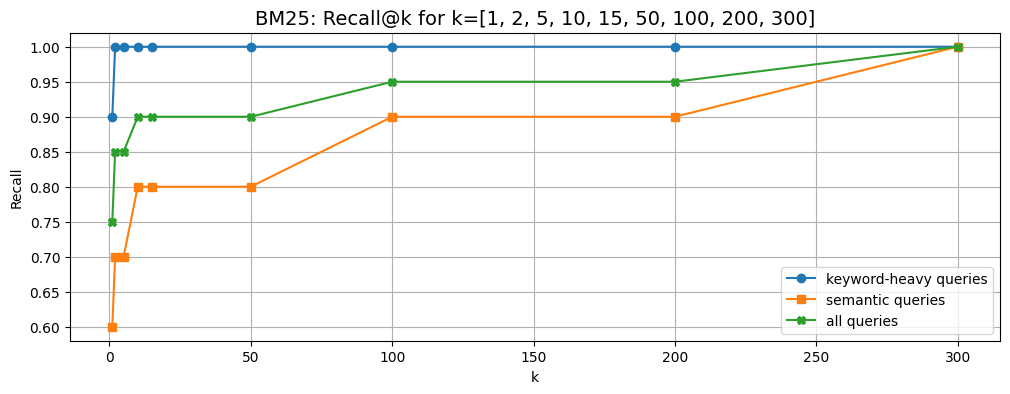

In [ ]:
# @title Evaluate keyword search recall@k for various k values
recalls = []
for k in ALL_KS:
    recalls.append(recall_at_k(keyword_search, k=k))
fig = plt.figure(figsize=(12, 4))
plt.plot(ALL_KS, [r['keyword'] for r in recalls], marker='o', label='keyword-heavy queries')
plt.plot(ALL_KS, [r['vector'] for r in recalls], marker='s', label='semantic queries')
plt.plot(ALL_KS, [(r['keyword'] + r['vector'])/2 for r in recalls], marker='X', label='all queries')
plt.xlabel('k')
plt.ylabel('Recall')
plt.title('BM25: Recall@k for k={}'.format(ALL_KS), fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

For keyword-heavy queries, Recall@1 is already at 0.9 and Recall@2 achieves the perfect score 1. In contrast, BM25 struggles with semantic queries: even at k=100 it still misses the gold chunk for one query!

## Part 2: add vector search 🧠 🎯

Vector (dense) search embeds the query with the **same model** used for the corpus, then ranks by cosine similarity. It matches **meaning**, so it survives vocabulary mismatch.


In [ ]:
# @title Initialize the embedding model and loading the embeddings of the chunks
model = SentenceTransformer(EMB_MODEL_NAME)
print(f"Loading embeddings created with {EMB_MODEL_NAME} ...")
with open("02_cx_embeddings.pkl", "rb") as f:
    embeddings = pickle.load(f)

print(f"Number of chunks:    {len(chunks)}")
print(f"Dimension of embeddings: {embeddings.shape[1]}")

Embedding with sentence-transformers/all-MiniLM-L6-v2 ...
Number of chunks:    14204
Dimension of embeddings: 384


In [ ]:
def embed_query(query):
    v = model.encode([query], normalize_embeddings=True)[0]
    return v.astype(np.float32)

def vector_search(query, k=3):
    qv = embed_query(query)
    # 🎯 TODO: compute the cosine similarity between the query vector and all chunk vectors
    cos_sim = ...  # cosine similarity vector, shape (num_chunks,)

    # 🎯 TODO: Retrieve the indices of the k-highest scoring chunks
    idx = ...  # indices of the k-highest scoring chunks

    return [(int(i), float(cos_sim[i])) for i in idx]

In [ ]:
# @title Test on two sample queries {display-mode: "form"}
def display_vector_search_comparison(q1_info, q2_info):
    """Render a side-by-side Cosine Similarity evaluation UI in Jupyter Notebook.

    q1_info and q2_info expect dicts formatted as:
    {
        'query': str,
        'gold_id': str,
        'gold_text': str,
        'matches': [(score, chunk_id, text), ...]
    }
    """

    def render_query_column(data, title):
        matches_html = ""
        for score, chunk_id, text in data["matches"]:
            is_gold = chunk_id == data["gold_id"]
            badge_class = "gold-badge" if is_gold else "match-badge"
            badge_label = "GOLD MATCH" if is_gold else "MATCH"

            matches_html += f"""
            <div class="match-card {'is-gold-card' if is_gold else ''}">
                <div class="match-header">
                    <span class="cos-score">Cos-Sim: <strong>{score:.4f}</strong></span>
                    <span class="chunk-id">{chunk_id}</span>
                    <span class="{badge_class}">{badge_label}</span>
                </div>
                <div class="chunk-text">{text}</div>
            </div>
            """

        return f"""
        <div class="query-column">
            <div class="col-header">{title}</div>
            <div class="section-box">
                <div class="box-label">QUERY</div>
                <p class="query-text">{data['query']}</p>
            </div>

            <div class="section-box gold-box">
                <div class="box-label gold-label">GOLD DOCUMENT ({data['gold_id']})</div>
                <div class="chunk-text">{data['gold_text']}</div>
            </div>

            <div class="section-box">
                <div class="box-label">TOP MATCHES (VECTOR / COS-SIM)</div>
                {matches_html}
            </div>
        </div>
        """

    html_content = f"""
    <style>
        .vector-container {{
            font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, Helvetica, Arial, sans-serif;
            display: flex;
            gap: 20px;
            background-color: #fcfaff;
            padding: 20px;
            border-radius: 12px;
            border: 1px solid #f0e6ff;
            color: #212529;
            box-sizing: border-box;
        }}
        .query-column {{
            flex: 1;
            display: flex;
            flex-direction: column;
            gap: 16px;
            min-width: 0;
        }}
        .col-header {{
            font-size: 14px;
            font-weight: 700;
            text-transform: uppercase;
            letter-spacing: 0.5px;
            color: #531dab;
            padding-bottom: 8px;
            border-bottom: 2px solid #d3ade6;
        }}
        .section-box {{
            background: #ffffff;
            border: 1px solid #e8e0f0;
            border-radius: 8px;
            padding: 12px 14px;
            box-shadow: 0 1px 3px rgba(83, 29, 171, 0.03);
        }}
        .gold-box {{
            background: #f9f0ff;
            border-color: #d3ade6;
        }}
        .box-label {{
            font-size: 11px;
            font-weight: 700;
            color: #8c8c8c;
            letter-spacing: 0.5px;
            margin-bottom: 6px;
        }}
        .gold-label {{
            color: #722ed1;
        }}
        .query-text {{
            margin: 0;
            font-size: 14px;
            font-weight: 600;
            color: #1f1f1f;
            line-height: 1.4;
        }}
        .chunk-text {{
            font-size: 12px;
            color: #434343;
            line-height: 1.5;
            max-height: 120px;
            overflow-y: auto;
            white-space: pre-wrap;
            word-break: break-word;
        }}
        .match-card {{
            background: #fafafa;
            border: 1px solid #f0f0f0;
            border-radius: 6px;
            padding: 10px;
            margin-bottom: 8px;
        }}
        .match-card:last-child {{
            margin-bottom: 0;
        }}
        .is-gold-card {{
            background: #f6ffed;
            border-color: #b7eb8f;
        }}
        .match-header {{
            display: flex;
            align-items: center;
            gap: 8px;
            margin-bottom: 6px;
            font-size: 12px;
        }}
        .cos-score {{
            color: #531dab;
            background: #f9f0ff;
            padding: 2px 6px;
            border-radius: 4px;
            border: 1px solid #d3ade6;
            font-family: SFMono-Regular, Consolas, "Liberation Mono", Menlo, monospace;
        }}
        .chunk-id {{
            font-family: SFMono-Regular, Consolas, "Liberation Mono", Menlo, monospace;
            font-weight: 600;
            color: #595959;
        }}
        .gold-badge {{
            margin-left: auto;
            font-size: 10px;
            font-weight: 700;
            background: #52c41a;
            color: white;
            padding: 2px 6px;
            border-radius: 10px;
        }}
        .match-badge {{
            margin-left: auto;
            font-size: 10px;
            font-weight: 600;
            background: #f9f0ff;
            color: #722ed1;
            padding: 2px 6px;
            border-radius: 10px;
        }}
    </style>

    <div class="vector-container">
        {render_query_column(q1_info, "Query 1")}
        {render_query_column(q2_info, "Query 2")}
    </div>
    """
    display(HTML(html_content))

# 1. Format Query 1
q1_info = {
    "query": q1,
    "gold_id": "arxiv_20::c0",
    "gold_text": chunks[chunks["chunk_id"] == "arxiv_20::c0"].iloc[0]["text"],
    "matches": [
        (s, chunks.iloc[i]["chunk_id"], chunks.iloc[i]["text"])
        for i, s in vector_search(q1, k=3)
    ],
}

# 2. Format Query 2
q2_info = {
    "query": q2,
    "gold_id": "arxiv_2513::c0",
    "gold_text": chunks[chunks["chunk_id"] == "arxiv_2513::c0"].iloc[0]["text"],
    "matches": [
        (s, chunks.iloc[i]["chunk_id"], chunks.iloc[i]["text"])
        for i, s in vector_search(q2, k=3)
    ],
}

# 3. Display Side-by-Side
display_vector_search_comparison(q1_info, q2_info)

As expected, dense retrieval successfully find the gold chunk for the second query. Notice how it also finds the gold chunk for the keyword-heavy query because of semantic similarity. This is not always the case as we can see below.

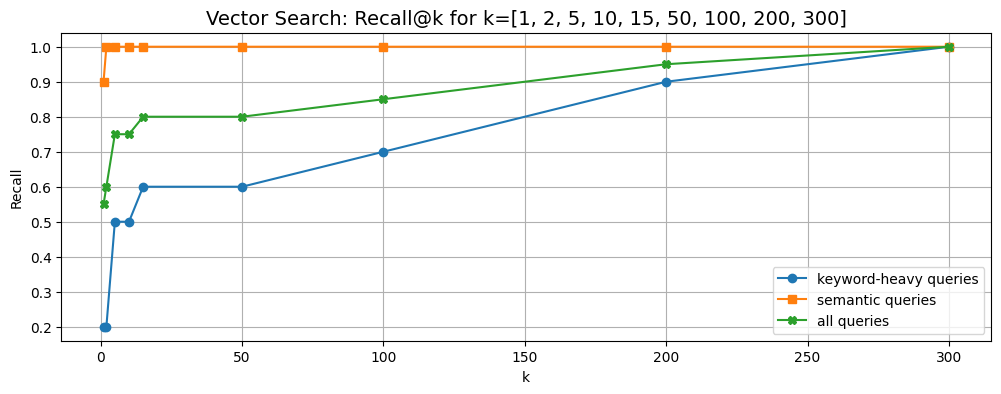

In [ ]:
# @title Evaluate keyword search recall@k for various k values {display-mode: "form"}
recalls = []
for k in ALL_KS:
    recalls.append(recall_at_k(vector_search, k=k))
fig = plt.figure(figsize=(12, 4))
plt.plot(ALL_KS, [r['keyword'] for r in recalls], marker='o', label='keyword-heavy queries')
plt.plot(ALL_KS, [r['vector'] for r in recalls], marker='s', label='semantic queries')
plt.plot(ALL_KS, [(r['keyword'] + r['vector'])/2 for r in recalls], marker='X', label='all queries')
plt.xlabel('k')
plt.ylabel('Recall')
plt.title('Vector Search: Recall@k for k={}'.format(ALL_KS), fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

Even at K=100, vector search only achieves a score of 0.7 on the keyword-heavy split, which is worse than BM25's Recall@1. We see that both methods have their strengths and weaknesses.

## Part 3: fuse them into hybrid search 🔀 🎯

A retrieval algorithm takes in a query and returns a ranked list of documents, best first. Keyword search and vector search are both such examples, and they have different opinion about what "best" means. BM25 scores might run from 0 to inifity, whereas cosine similarity runs from -1 to 1, so we cannot just add them together and expect a fair comparison. The fix is to ignore the raw scores and use only each document's position in its list, its **rank** (rank 1 is the top result, rank 2 is second, and so on). This is what **Reciprocal Rank Fusion (RRF)** does:

$$\text{score}(d) = \sum_{r \in \text{retrievers}} \frac{1}{k + \text{rank}_r(d)}$$

In words: a document that sits high in a list (a small rank, like 1 or 2) earns a lot of points, one that sits low earns very few. A document that ranks decently in *both* lists collects points from both and rises to the top of the merged ranking, which is exactly what we want from a hybrid method: reward documents that multiple retrievers agree on. `k` is a smoothing constant, usually set to 60.

In [ ]:
from typing import List, Tuple
def reciprocal_rank_fusion(rankings: List[List[Tuple[int, float]]], k=60, topk=20):
    fused = {} # candidates appearing in any ranking, with their fused score
    for ranking in rankings:
        for rank_minus_1, (i, _) in enumerate(ranking): # python is 0-indexed, but RRF requires 1-based rank
            # 🎯 TODO: Increment the RRF score of chunk i according to the formula
            # Hint: The formula is 1 / (k + rank), where rank is 1-based (so add 1 to rank_minus_1)
            fused[i] = fused.get(i, 0.0) + ...

    order = sorted(fused, key=fused.get, reverse=True)[:topk]
    return [(i, fused[i]) for i in order]

def hybrid_search(query, k=5, overretrieve_factor=20):
    kw = keyword_search(query, k=overretrieve_factor*k)
    vec = vector_search(query, k=overretrieve_factor*k)
    return reciprocal_rank_fusion([kw, vec], topk=k)

Finally, we compare all three methods (BM25, dense cosine similarity and RRF) across different k values:

In [ ]:
#@title Compute recall@k for each method across k values {display-mode: "form"}
methods = {"keyword": keyword_search, "vector": vector_search, "hybrid": hybrid_search}
types = ["keyword", "vector"]
all_scores = {name: [] for name in methods.keys()}
all_return_at_k = {name: [] for name in methods.keys()}
for name, fn in methods.items():
    for k in ALL_KS:
        r = recall_at_k(fn, k=k)
        all_scores[name].append(r)
for name, scores in all_scores.items():
    kw_q = [r['keyword'] for r in scores]
    vec_q = [r['vector'] for r in scores]
    all_return_at_k[name] = {"keyword": kw_q, "vector": vec_q}


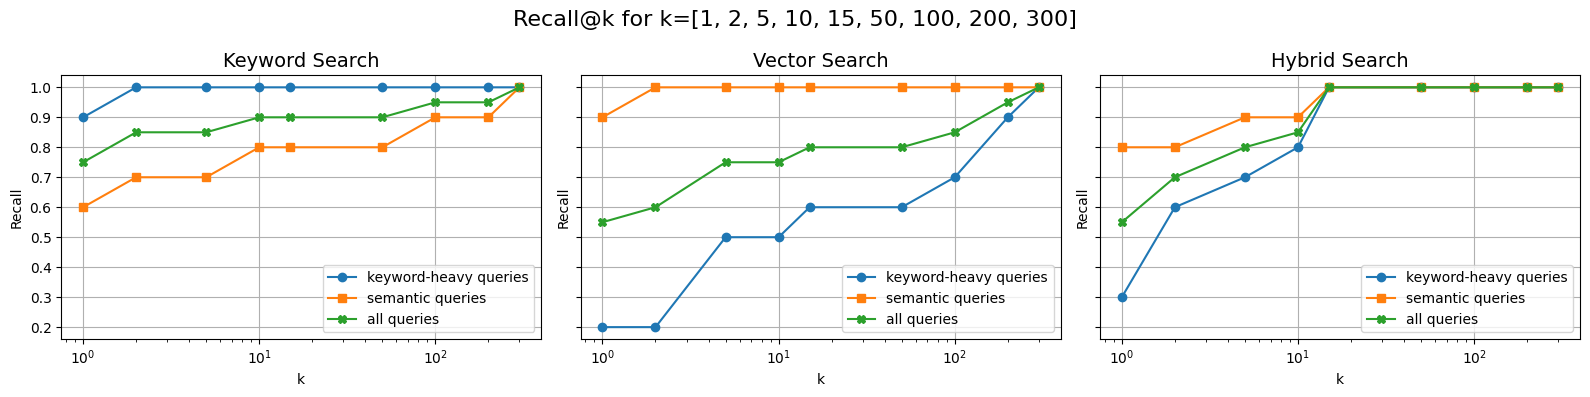

In [ ]:
# @title Plot Recall@k for each method across k values {display-mode: "form"}
fig, ax = plt.subplots(1,3, figsize=(16, 4), sharey=True)
for i, name in enumerate(methods.keys()):
    scores = np.array(list(all_scores[name]))
    ax[i].plot(ALL_KS, all_return_at_k[name]['keyword'], marker='o', label='keyword-heavy queries')
    ax[i].plot(ALL_KS, all_return_at_k[name]['vector'], marker='s', label='semantic queries')
    ax[i].plot(ALL_KS, (np.array(all_return_at_k[name]['keyword']) + np.array(all_return_at_k[name]['vector']))/2, marker='X', label='all queries')
    ax[i].set_xlabel('k')
    ax[i].set_ylabel('Recall')
    ax[i].set_xscale('log')
    ax[i].set_title(f'{name.capitalize()} Search', fontsize=14)
    ax[i].legend(loc='lower right')
    ax[i].grid(True)
plt.suptitle('Recall@k for k={}'.format(ALL_KS), fontsize=16)
plt.tight_layout()

**The lesson, in one line:** BM25 wins on exact terms, dense retrieval wins on meaning, and hybrid search sits in between with no glaring weakness but a bit worse than the other two for extreme queries. Hybrid search also gives you the fastest return@k saturation. In production you do not know which query is coming next, so you want the most robust method that does resaonably well under all circumstances.


## Part 4: scale up, and meet ANN ⚡

So far, vector search compared the query against **every** document, one by one. This is called a brute-force or exact scan. With a few thousand chunks it is instant. Real corpora hold millions of vectors, and scanning all of them per query becomes too slow.

We do not have millions of real abstracts on hand, so to feel the scaling problem we grow our index to a larger number of vectors and measure how search time behaves as the index grows. The exact contents matter less here than the trend: what happens to latency as the number of vectors increases, and what ANN buys us in return.

The lesson holds regardless of how the large index is produced: exact search cost rises with the number of vectors, and Approximate Nearest Neighbor search keeps latency nearly flat by trading away a small, tunable amount of recall.

In [ ]:
#@title Build a larger synthetic index for the scaling demo (run me)
rng = np.random.default_rng(0)
def inflate(base, target):
    need = target - len(base)
    src = base[rng.integers(0, len(base), size=need)]
    src = src + rng.normal(scale=0.05, size=src.shape).astype(np.float32)
    big = np.vstack([base, src])
    big /= np.linalg.norm(big, axis=1, keepdims=True) # normalize to unit length
    return big.astype(np.float32)

big = inflate(embeddings, 60000)
print("inflated index:", big.shape)

inflated index: (60000, 384)


### 4.1 Brute force gets slow, linearly, with the size of dataset N ⏳

Heads-up: this curve runs on a small, fabricated index (a few thousand to 60k vectors, built by perturbing real embeddings) so the demo finishes in class. Do not read the millisecond numbers as production benchmarks. The takeaway that generalizes is the shape, not the numbers: exact brute-force search compares the query against every vector, so its cost grows linearly with N. That is exactly why large corpora (millions of vectors) need ANN instead. 📈


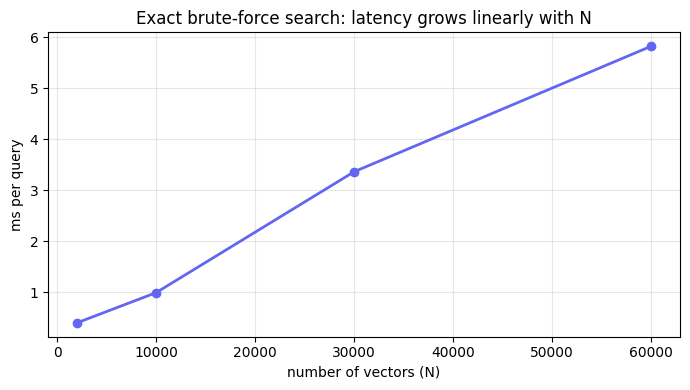

latency ms: [0.4, 0.99, 3.36, 5.83]


In [ ]:
#@title Visualization: exact search latency vs index size {display-mode: "form"}
def exact_topk(mat, qv, k=10):
    return np.argsort(-(mat @ qv))[:k]

qv = big[0]
Ns, lat = [2000, 10000, 30000, 60000], []
for n in Ns:
    sub = big[:n]
    t0 = time.time()
    for _ in range(50): exact_topk(sub, qv)
    lat.append((time.time()-t0)/50*1000)

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(Ns, lat, "o-", color="#6366f1", lw=2)
ax.set_xlabel("number of vectors (N)"); ax.set_ylabel("ms per query")
ax.set_title("Exact brute-force search: latency grows linearly with N")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("latency ms:", [round(x,2) for x in lat])

In [ ]:
# @title Visual: how approximate nearest neighbor search works {display-mode: "form"}

html_ann_visual = """
<style>
    .ann-container {
        font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, Helvetica, Arial, sans-serif;
        background-color: #f8f9fa;
        border: 1px solid #e9ecef;
        border-radius: 12px;
        padding: 24px 20px 16px 20px;
        color: #212529;
        box-sizing: border-box;
        margin: 14px 0;
    }
    .ann-header-title {
        font-size: 16px;
        font-weight: 700;
        color: #1f1f1f;
        text-align: center;
        letter-spacing: -0.2px;
        margin-bottom: 4px;
    }
    .ann-header-subtitle {
        font-size: 13px;
        color: #595959;
        text-align: center;
        margin-bottom: 12px;
    }
    .ann-svg text.h-title { font: 700 14px -apple-system, sans-serif; fill: #1f1f1f; }
    .ann-svg text.b-title { font: 700 12px -apple-system, sans-serif; fill: #531dab; }
    .ann-svg text.sub-txt { font: 12px -apple-system, sans-serif; fill: #595959; }
    .ann-svg text.caption { font: 11px -apple-system, sans-serif; fill: #8c8c8c; }
    .ann-svg text.num-lbl { font: 700 10px -apple-system, sans-serif; fill: #ffffff; }
    .ann-svg text.node-lbl { font: 600 11px -apple-system, sans-serif; fill: #262626; }
</style>

<div class="ann-container">
    <div class="ann-header-title">How Approximate Nearest Neighbor (ANN) Search Works</div>
    <div class="ann-header-subtitle">Exact search compares every vector. ANN navigates a graph to find near-neighbors in O(log N) time.</div>

    <div style="text-align:center; width:100%;">
    <svg class="ann-svg" viewBox="0 0 860 310" width="100%" style="max-width:860px;">
      <defs>
        <!-- Arrowhead marker matching theme purple -->
        <marker id="annHop" markerWidth="8" markerHeight="8" refX="6" refY="4" orient="auto">
          <path d="M0,0 L8,4 L0,8 z" fill="#722ed1"/>
        </marker>
      </defs>

      <!-- Vertical Column Dividers -->
      <line x1="286" y1="10" x2="286" y2="300" stroke="#e8e8e8" stroke-width="1" stroke-dasharray="4,4"/>
      <line x1="573" y1="10" x2="573" y2="300" stroke="#e8e8e8" stroke-width="1" stroke-dasharray="4,4"/>

      <!-- ================= COLUMN 1: EXACT SEARCH ================= -->
      <text class="h-title" x="143" y="25" text-anchor="middle">1. Exact Search</text>

      <!-- Edges to all nodes -->
      <g stroke="#d9d9d9" stroke-width="1.2">
        <line x1="143" y1="135" x2="50"  y2="80"/>
        <line x1="143" y1="135" x2="95"  y2="65"/>
        <line x1="143" y1="135" x2="175" y2="65"/>
        <line x1="143" y1="135" x2="230" y2="90"/>
        <line x1="143" y1="135" x2="240" y2="145"/>
        <line x1="143" y1="135" x2="210" y2="190"/>
        <line x1="143" y1="135" x2="143" y2="205"/>
        <line x1="143" y1="135" x2="75"  y2="190"/>
        <line x1="143" y1="135" x2="40"  y2="135"/>
      </g>

      <!-- Database Nodes -->
      <g fill="#bfbfbf">
        <circle cx="50"  cy="80"  r="5"/>
        <circle cx="95"  cy="65"  r="5"/>
        <circle cx="175" cy="65"  r="5"/>
        <circle cx="230" cy="90"  r="5"/>
        <circle cx="240" cy="145" r="5"/>
        <circle cx="210" cy="190" r="5"/>
        <circle cx="143" cy="205" r="5"/>
        <circle cx="75"  cy="190" r="5"/>
        <circle cx="40"  cy="135" r="5"/>
      </g>

      <!-- Query Node -->
      <circle cx="143" cy="135" r="7" fill="#1677ff"/>
      <text class="node-lbl" x="143" y="156" text-anchor="middle">Query</text>

      <text class="sub-txt" x="143" y="245" font-weight="600" text-anchor="middle">Scans 100% of vectors</text>
      <text class="caption" x="143" y="263" text-anchor="middle">Complexity: O(N) • 100% Exact</text>

      <!-- ================= COLUMN 2: ANN GRAPH HOPS ================= -->
      <text class="h-title" x="430" y="25" text-anchor="middle">2. ANN Graph Traversal</text>

      <!-- Graph structure background lines -->
      <g stroke="#e8e8e8" stroke-width="1">
        <line x1="310" y1="70" x2="370" y2="60"/>
        <line x1="370" y1="60" x2="430" y2="65"/>
        <line x1="430" y1="65" x2="420" y2="135"/>
        <line x1="310" y1="70" x2="340" y2="160"/>
        <line x1="340" y1="160" x2="320" y2="195"/>
        <line x1="340" y1="160" x2="410" y2="190"/>
        <line x1="410" y1="190" x2="470" y2="155"/>
        <line x1="410" y1="190" x2="460" y2="200"/>
      </g>

      <!-- Directed Hop Vector Arrows -->
      <g stroke="#722ed1" stroke-width="2.5" marker-end="url(#annHop)">
        <line x1="310" y1="70" x2="358" y2="117"/>
        <line x1="360" y1="120" x2="418" y2="133"/>
        <line x1="420" y1="135" x2="468" y2="153"/>
        <line x1="470" y1="155" x2="502" y2="168"/>
      </g>

      <!-- Unvisited graph nodes -->
      <g fill="#d9d9d9">
        <circle cx="370" cy="60"  r="5"/>
        <circle cx="430" cy="65"  r="5"/>
        <circle cx="340" cy="160" r="5"/>
        <circle cx="320" cy="195" r="5"/>
        <circle cx="410" cy="190" r="5"/>
        <circle cx="460" cy="200" r="5"/>
      </g>

      <!-- Path visited nodes -->
      <g fill="#722ed1">
        <circle cx="310" cy="70"  r="6"/>
        <circle cx="360" cy="120" r="5"/>
        <circle cx="420" cy="135" r="5"/>
        <circle cx="470" cy="155" r="5"/>
        <circle cx="505" cy="170" r="6"/>
      </g>

      <!-- Target Query Point (dashed boundary) -->
      <circle cx="528" cy="178" r="7" fill="none" stroke="#1677ff" stroke-width="2" stroke-dasharray="3,2"/>
      <text class="node-lbl" x="540" y="182" text-anchor="start">Query</text>
      <text class="node-lbl" x="310" y="52"  text-anchor="middle">Entry</text>

      <!-- Hop sequence Badges -->
      <g fill="#722ed1">
        <circle cx="335" cy="88"  r="6.5"/>
        <circle cx="390" cy="115" r="6.5"/>
        <circle cx="445" cy="133" r="6.5"/>
        <circle cx="490" cy="150" r="6.5"/>
      </g>
      <g class="num-lbl" text-anchor="middle">
        <text x="335" y="91.5">1</text>
        <text x="390" y="118.5">2</text>
        <text x="445" y="136.5">3</text>
        <text x="490" y="153.5">4</text>
      </g>

      <text class="sub-txt" x="430" y="245" font-weight="600" text-anchor="middle">Greedy walk towards query</text>
      <text class="caption" x="430" y="263" text-anchor="middle">Complexity: ~O(log N) • Fast & Scalable</text>

      <!-- ================= COLUMN 3: RECALL & EF TRADEOFF ================= -->
      <text class="h-title" x="716" y="25" text-anchor="middle">3. Precision vs Speed</text>

      <!-- Miss connection line -->
      <line x1="735" y1="138" x2="675" y2="148" stroke="#ff4d4f" stroke-width="1.5" stroke-dasharray="3,2"/>

      <!-- Query point -->
      <circle cx="700" cy="120" r="6" fill="#1677ff"/>
      <text class="node-lbl" x="700" y="104" text-anchor="middle">Query</text>

      <!-- True Nearest Neighbor -->
      <circle cx="735" cy="138" r="6" fill="#ffffff" stroke="#52c41a" stroke-width="2.5"/>
      <text class="node-lbl" x="735" y="160" text-anchor="middle" fill="#389e0d">True 1-NN</text>

      <!-- Stop point -->
      <circle cx="675" cy="148" r="6" fill="#722ed1"/>
      <text class="node-lbl" x="662" y="170" text-anchor="middle" fill="#531dab">ANN Result</text>

      <text class="sub-txt" x="716" y="225" font-weight="600" text-anchor="middle">Controlled by `ef_search`</text>
      <text class="caption" x="716" y="243" text-anchor="middle">Higher `ef` = Higher Recall, Lower Speed</text>
      <text class="caption" x="716" y="260" text-anchor="middle">Lower `ef` = Sub-millisecond, Local Minima</text>
    </svg>
    </div>
</div>
"""

display(HTML(html_ann_visual))

A little bit of math to make the payoff concrete:

- **Exact search** is O(N*d) per query: it compares the query to all N vectors of dimension d.
- **HNSW** is about O(d*log N) per query: it navigates a layered graph from coarse to fine instead of scanning.
- **The H in HNSW is hierarchy**: sparse layers on top for big jumps, dense layers below for fine steps, which is where the log N comes from.
- **ef_search** is how many candidate nodes the search keeps in play while walking the graph, so it directly controls the recall versus latency point you will plot next.

One more family worth knowing: IVF (inverted file index) groups vectors into clusters and only searches the nearest few clusters, tuned by a parameter called nprobe. 🧭


### 4.2 ANN: same query, far less time, but recall drops below 1.0

**HNSW** (Hierarchical Navigable Small World) builds a graph and only visits a small neighborhood per query, so latency stays almost flat as N grows. The catch: it is **approximate**. It may miss some true neighbors. We measure that against the exact answer.


In [ ]:
#@title Build the HNSW index and define the ANN eval helper (run me)
dim = big.shape[1]
index = hnswlib.Index(space="cosine", dim=dim)
index.init_index(max_elements=len(big), ef_construction=100, M=12)
index.add_items(big, np.arange(len(big)))

# ground truth from exact search on a sample of queries
queries = big[:200]
gold = [set(exact_topk(big, q, 10).tolist()) for q in queries]

def ann_eval(ef, k=10):
    index.set_ef(ef)
    hits = 0; t0 = time.time()
    for i, q in enumerate(queries):
        labels, _ = index.knn_query(q, k=k)
        hits += len(gold[i] & set(labels[0].tolist()))
    dt = (time.time()-t0)/len(queries)*1000
    return hits/(len(queries)*k), dt

r, dt = ann_eval(ef=10)
print('Size of Database:', len(big))
print(f"HNSW (ef=10): recall@10={r:.3f}   {dt:.3f}  ms/query")
print(f"Exact NN    : recall@10=1.000   {lat[-1]:.2f}   ms/query")
print("HNSW keeps a fraction of the true neighbors, for a large speedup.")

Size of Database: 60000
HNSW (ef=10): recall@10=0.890   0.110  ms/query
Exact NN    : recall@10=1.000   5.83   ms/query
HNSW keeps a fraction of the true neighbors, for a large speedup.


### 4.3 The tradeoff is a knob: recall vs latency 🎚️

`ef_search` controls how much of the graph HNSW explores. Higher `ef` means higher recall and higher latency. Sweep it and plot the Pareto curve. You **choose** where to sit.


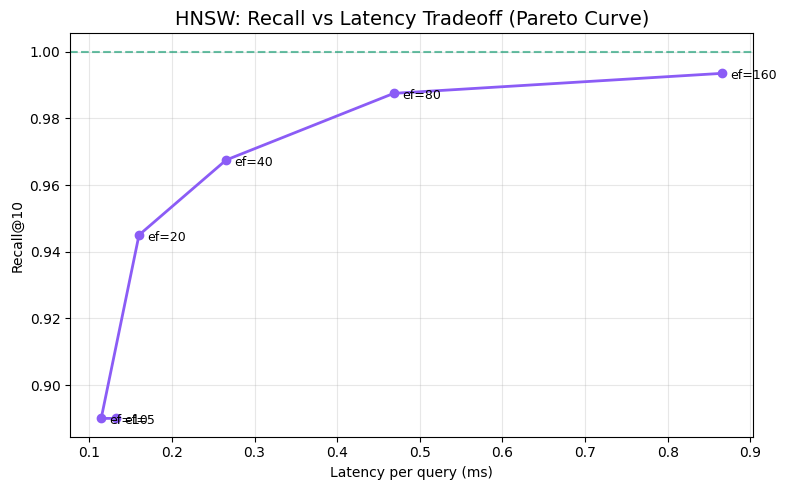

recall: [0.89, 0.89, 0.945, 0.968, 0.988, 0.994]
latency: [0.133, 0.114, 0.16, 0.266, 0.469, 0.866]


In [ ]:
#@title Visualization: recall vs latency Pareto curve {display-mode: "form"}
efs = [5, 10, 20, 40, 80, 160]
recs, lats = [], []
for ef in efs:
    r, dt = ann_eval(ef)
    recs.append(r); lats.append(dt)

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(lats, recs, "o-", color="#8b5cf6", lw=2)
for ef, x, y in zip(efs, lats, recs):
    ax.annotate(f"ef={ef}", (x, y), textcoords="offset points", xytext=(6,-4), fontsize=9)
ax.axhline(1.0, ls="--", color="#059669", alpha=0.6)
ax.set_xlabel("Latency per query (ms)"); ax.set_ylabel("Recall@10")
ax.set_title("HNSW: Recall vs Latency Tradeoff (Pareto Curve)", fontsize=14)
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("recall:", [round(r,3) for r in recs])
print("latency:", [round(l,3) for l in lats])

In [ ]:
#@title Visualization: exact search vs ANN search, side by side {display-mode: "form"}
html_ann_side_by_side = """
<style>
    .cmp-container {
        font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, Helvetica, Arial, sans-serif;
        display: flex;
        gap: 20px;
        background-color: #f8f9fa;
        padding: 20px;
        border-radius: 12px;
        border: 1px solid #e9ecef;
        color: #212529;
        box-sizing: border-box;
        margin: 14px 0;
    }
    .cmp-column {
        flex: 1;
        display: flex;
        flex-direction: column;
        gap: 12px;
        min-width: 0;
        background: #ffffff;
        border: 1px solid #e0e0e0;
        border-radius: 8px;
        padding: 16px;
        box-shadow: 0 1px 3px rgba(0,0,0,0.03);
    }
    .cmp-column.ann-col {
        background: #fcfaff;
        border-color: #e8e0f0;
    }
    .cmp-header {
        display: flex;
        align-items: center;
        justify-content: space-between;
        padding-bottom: 8px;
        border-bottom: 2px solid #f0f0f0;
    }
    .ann-col .cmp-header {
        border-bottom-color: #d3ade6;
    }
    .cmp-title {
        font-size: 14px;
        font-weight: 700;
        color: #1f1f1f;
    }
    .ann-col .cmp-title {
        color: #531dab;
    }
    .badge-exact {
        font-size: 10px;
        font-weight: 700;
        background: #e6f4ff;
        color: #1677ff;
        padding: 2px 8px;
        border-radius: 10px;
        letter-spacing: 0.3px;
    }
    .badge-ann {
        font-size: 10px;
        font-weight: 700;
        background: #f9f0ff;
        color: #722ed1;
        padding: 2px 8px;
        border-radius: 10px;
        letter-spacing: 0.3px;
    }
    .svg-wrapper {
        text-align: center;
        margin: 8px 0;
    }
    .cmp-footer {
        background: #fafafa;
        border-radius: 6px;
        padding: 8px 12px;
        border: 1px solid #f0f0f0;
        font-size: 12px;
        color: #595959;
        display: flex;
        justify-content: space-between;
        align-items: center;
    }
    .ann-col .cmp-footer {
        background: #ffffff;
        border-color: #f0e6ff;
    }
    .metric-tag {
        font-family: SFMono-Regular, Consolas, "Liberation Mono", Menlo, monospace;
        font-weight: 600;
        font-size: 11px;
    }
</style>

<div class="cmp-container">
    <!-- LEFT COLUMN: EXACT SEARCH -->
    <div class="cmp-column">
        <div class="cmp-header">
            <span class="cmp-title">1. Exact Search</span>
            <span class="badge-exact">EXACT</span>
        </div>

        <div class="svg-wrapper">
            <svg viewBox="0 0 380 210" width="100%" style="max-width:380px;">
                <!-- Full comparison lines -->
                <g stroke="#d9d9d9" stroke-width="1.2">
                    <line x1="190" y1="105" x2="80"  y2="35"/>
                    <line x1="190" y1="105" x2="140" y2="25"/>
                    <line x1="190" y1="105" x2="240" y2="20"/>
                    <line x1="190" y1="105" x2="310" y2="55"/>
                    <line x1="190" y1="105" x2="320" y2="125"/>
                    <line x1="190" y1="105" x2="290" y2="175"/>
                    <line x1="190" y1="105" x2="210" y2="195"/>
                    <line x1="190" y1="105" x2="110" y2="185"/>
                    <line x1="190" y1="105" x2="70"  y2="135"/>
                    <line x1="190" y1="105" x2="60"  y2="85"/>
                </g>
                <!-- Database points -->
                <g fill="#bfbfbf">
                    <circle cx="80"  cy="35"  r="5"/>
                    <circle cx="140" cy="25"  r="5"/>
                    <circle cx="240" cy="20"  r="5"/>
                    <circle cx="310" cy="55"  r="5"/>
                    <circle cx="320" cy="125" r="5"/>
                    <circle cx="290" cy="175" r="5"/>
                    <circle cx="210" cy="195" r="5"/>
                    <circle cx="110" cy="185" r="5"/>
                    <circle cx="70"  cy="135" r="5"/>
                    <circle cx="60"  cy="85"  r="5"/>
                </g>
                <!-- Query center point -->
                <circle cx="190" cy="105" r="8" fill="#1677ff"/>
            </svg>
        </div>

        <div class="cmp-footer">
            <span>Compares query with every vector</span>
            <span class="metric-tag" style="color: #1677ff;">O(N)</span>
        </div>
    </div>

    <!-- RIGHT COLUMN: ANN SEARCH -->
    <div class="cmp-column ann-col">
        <div class="cmp-header">
            <span class="cmp-title">2. Graph ANN Search</span>
            <span class="badge-ann">APPROXIMATE</span>
        </div>

        <div class="svg-wrapper">
            <svg viewBox="0 0 380 210" width="100%" style="max-width:380px;">
                <!-- Unvisited background nodes -->
                <g fill="#d9d9d9">
                    <circle cx="130" cy="55"  r="4"/>
                    <circle cx="90"  cy="115" r="4"/>
                    <circle cx="330" cy="175" r="4"/>
                </g>
                <!-- Graph hop path -->
                <g stroke="#722ed1" stroke-width="2.5" stroke-linecap="round">
                    <line x1="190" y1="105" x2="270" y2="55"/>
                    <line x1="270" y1="55"  x2="300" y2="115"/>
                    <line x1="300" y1="115" x2="230" y2="165"/>
                </g>
                <!-- Visited graph nodes -->
                <g fill="#722ed1">
                    <circle cx="270" cy="55"  r="5.5"/>
                    <circle cx="300" cy="115" r="5.5"/>
                    <circle cx="230" cy="165" r="5.5"/>
                </g>
                <!-- Query start point -->
                <circle cx="190" cy="105" r="8" fill="#531dab"/>
            </svg>
        </div>

        <div class="cmp-footer">
            <span>Hops through graph neighborhood</span>
            <span class="metric-tag" style="color: #722ed1;">~O(log N)</span>
        </div>
    </div>
</div>
"""

display(HTML(html_ann_side_by_side))

Look at the low-`ef` end of the Pareto curve: recall is below 1.0. **A missed neighbor means the RAG silently drops a relevant chunk**, so the LLM answers without it, and the student gets an off-topic reply.

## Part 5: RAG in Action 🤖

Retrieval quality is not abstract: it decides what the LLM sees. We feed the retrieved context to the model and compare a **good** retrieval against a **bad** one on the same question.


In [ ]:
#@title Set up the LLM client (run me, needs an API key from OpenRouter or Google AI Studio)
from getpass import getpass
import os
SECRET = {"env_var": "GOOGLE_API_KEY"}
api_key = os.environ.get(SECRET["env_var"]) or getpass(f"{SECRET['env_var']}: ")
client = genai.Client(api_key=api_key.strip())
llm_model = "gemini-3.5-flash-lite"
print(f"Using model: {llm_model} for generation")


Using model: gemini-3.5-flash-lite for generation


In [ ]:
# @title Helper function for rendering {display-mode: "form"}
def display_rag_comparison(q1_rag_data, q2_rag_data, system_instruction):
    """Render a side-by-side RAG pipeline evaluation in Jupyter Notebook.

    Data format expected for q1_rag_data and q2_rag_data:
    {
        'query': str,
        'search_type': str,  # e.g. "BM25" or "Vector (Cos-Sim)"
        'hits': [(score, chunk_id, text), ...],
        'answer': str
    }
    """

    def render_column(data, title):
        # Build context chunks text
        ctx_formatted = "\n\n".join(
            f"[{n+1}] {text}" for n, (_, _, text) in enumerate(data["hits"])
        )

        # Build retrieved hits cards
        hits_html = ""
        for n, (score, chunk_id, text) in enumerate(data["hits"]):
            hits_html += f"""
            <div class="rag-chunk-card">
                <div class="rag-chunk-header">
                    <span class="chunk-index">[{n+1}]</span>
                    <span class="chunk-id">{chunk_id}</span>
                    <span class="score-badge">{data['search_type']}: <strong>{round(score, 4) if isinstance(score, float) and score < 1 else score}</strong></span>
                </div>
                <div class="chunk-body">{text}</div>
            </div>
            """

        return f"""
        <div class="rag-column">
            <div class="rag-col-header">{title}</div>

            <!-- 1. Question -->
            <div class="rag-section">
                <div class="rag-box-label">QUESTION</div>
                <div class="rag-query">{data['query']}</div>
            </div>

            <!-- 2. Retrieved Context Chunks -->
            <div class="rag-section">
                <div class="rag-box-label">RETRIEVED CONTEXT ({len(data['hits'])} CHUNKS)</div>
                {hits_html}
            </div>

            <!-- 3. Final Formatted Prompt -->
            <div class="rag-section prompt-box">
                <div class="rag-box-label prompt-label">FULL PROMPT PASSED TO LLM</div>
                <div class="rag-prompt-content">Context:
{ctx_formatted}

Question: {data['query']}
Answer:</div>
            </div>

            <!-- 4. Generated Answer -->
            <div class="rag-section answer-box">
                <div class="rag-box-label answer-label">GEMINI GENERATED ANSWER</div>
                <div class="rag-answer-content">{data['answer']}</div>
            </div>
        </div>
        """

    html_content = f"""
    <style>
        .rag-container {{
            font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, Helvetica, Arial, sans-serif;
            display: flex;
            gap: 20px;
            background-color: #f8f9fa;
            padding: 20px;
            border-radius: 12px;
            border: 1px solid #e9ecef;
            color: #212529;
            box-sizing: border-box;
            margin: 14px 0;
        }}
        .rag-column {{
            flex: 1;
            display: flex;
            flex-direction: column;
            gap: 14px;
            min-width: 0;
        }}
        .rag-col-header {{
            font-size: 14px;
            font-weight: 700;
            text-transform: uppercase;
            letter-spacing: 0.5px;
            color: #1f1f1f;
            padding-bottom: 8px;
            border-bottom: 2px solid #389e0d;
        }}
        .sys-banner {{
            background: #ffffff;
            border: 1px solid #d9d9d9;
            border-left: 4px solid #1677ff;
            border-radius: 6px;
            padding: 10px 14px;
            margin-bottom: 16px;
            font-size: 13px;
        }}
        .sys-title {{
            font-size: 11px;
            font-weight: 700;
            color: #1677ff;
            letter-spacing: 0.5px;
            margin-bottom: 2px;
        }}
        .sys-text {{
            font-family: SFMono-Regular, Consolas, "Liberation Mono", Menlo, monospace;
            color: #262626;
        }}
        .rag-section {{
            background: #ffffff;
            border: 1px solid #e0e0e0;
            border-radius: 8px;
            padding: 12px 14px;
            box-shadow: 0 1px 3px rgba(0,0,0,0.03);
        }}
        .rag-box-label {{
            font-size: 10px;
            font-weight: 700;
            color: #8c8c8c;
            letter-spacing: 0.5px;
            margin-bottom: 6px;
        }}
        .rag-query {{
            font-size: 14px;
            font-weight: 600;
            color: #1f1f1f;
            line-height: 1.4;
        }}
        .rag-chunk-card {{
            background: #fafafa;
            border: 1px solid #f0f0f0;
            border-radius: 6px;
            padding: 8px 10px;
            margin-bottom: 6px;
        }}
        .rag-chunk-card:last-child {{
            margin-bottom: 0;
        }}
        .rag-chunk-header {{
            display: flex;
            align-items: center;
            gap: 8px;
            font-size: 11px;
            margin-bottom: 4px;
        }}
        .chunk-index {{
            font-weight: 700;
            color: #389e0d;
        }}
        .chunk-id {{
            font-family: SFMono-Regular, Consolas, "Liberation Mono", Menlo, monospace;
            font-weight: 600;
            color: #595959;
        }}
        .score-badge {{
            margin-left: auto;
            font-size: 10px;
            background: #f6ffed;
            color: #389e0d;
            border: 1px solid #b7eb8f;
            padding: 1px 6px;
            border-radius: 4px;
        }}
        .chunk-body {{
            font-size: 12px;
            color: #434343;
            line-height: 1.4;
            max-height: 80px;
            overflow-y: auto;
            white-space: pre-wrap;
        }}
        .prompt-box {{
            background: #fdfaff;
            border-color: #f0e6ff;
        }}
        .prompt-label {{
            color: #722ed1;
        }}
        .rag-prompt-content {{
            font-family: SFMono-Regular, Consolas, "Liberation Mono", Menlo, monospace;
            font-size: 11px;
            color: #391085;
            line-height: 1.4;
            max-height: 110px;
            overflow-y: auto;
            white-space: pre-wrap;
            background: #ffffff;
            padding: 8px;
            border-radius: 4px;
            border: 1px solid #f0e6ff;
        }}
        .answer-box {{
            background: #f6ffed;
            border-color: #b7eb8f;
        }}
        .answer-label {{
            color: #389e0d;
        }}
        .rag-answer-content {{
            font-size: 13px;
            font-weight: 500;
            color: #135200;
            line-height: 1.5;
        }}
    </style>

    <div class="sys-banner">
        <div class="sys-title">GLOBAL SYSTEM INSTRUCTION</div>
        <div class="sys-text">"{system_instruction}"</div>
    </div>

    <div class="rag-container">
        {render_column(q1_rag_data, "Query 1 Generation")}
        {render_column(q2_rag_data, "Query 2 Generation")}
    </div>
    """
    display(HTML(html_content))

In [ ]:
# System prompt definition
SYS = "You answer strictly from the provided context. If the context does not contain the answer, say so."

def answer(query, search_fn, k=3):
    hits = search_fn(query, k=k)
    ctx = "\n\n".join(f"[{n+1}] {chunks.iloc[i]['text']}" for n,(i,_) in enumerate(hits))
    prompt = f"Context:\n{ctx}\n\nQuestion: {query}\nAnswer:"
    response = client.models.generate_content(
        model=llm_model,
        contents=prompt,
        config=genai.types.GenerateContentConfig(
            system_instruction=SYS,
        ),
)
    return response.text, hits

# 1. Execute RAG for Query 1
ans1, hits1 = answer(q1, hybrid_search, k=3)
q1_rag = {
    "query": q1,
    "search_type": "BM25",
    "hits": [(s, chunks.iloc[i]["chunk_id"], chunks.iloc[i]["text"]) for i, s in hits1],
    "answer": ans1,
}

# 2. Execute RAG for Query 2
ans2, hits2 = answer(q2, hybrid_search, k=3)
q2_rag = {
    "query": q2,
    "search_type": "BM25",
    "hits": [(s, chunks.iloc[i]["chunk_id"], chunks.iloc[i]["text"]) for i, s in hits2],
    "answer": ans2,
}

# 3. Render Visualization
display_rag_comparison(q1_rag, q2_rag, system_instruction=SYS)

(14204,)
(14204,)


## Your turn: try it yourself 🔍

Pick a search method, type any ML question (or click a sample below), and see what comes back, with scores. Try the same question under all three methods and watch where each one shines or struggles.

In [ ]:
#@title Helper: styled result renderer {display-mode: "form"}
def render_results(method_name, query, hits):
    scores = [s for _, s in hits]
    lo, hi = min(scores), max(scores)

    def normalize(s):
        # rescale to 0-1 within this result set, so keyword (BM25, unbounded),
        # vector (cosine, 0-1) and hybrid (RRF, tiny numbers) all look consistent
        if hi == lo:
            return 1.0
        return (s - lo) / (hi - lo)

    rows_html = []
    for rank, (i, score) in enumerate(hits, 1):
        norm = normalize(score)
        title = chunks.iloc[i]["title"]
        snippet = chunks.iloc[i]["text"][:160].replace("\n", " ").strip() + "..."
        gold = " 🏅" if chunks.iloc[i]["is_gold"] else ""
        rows_html.append(f"""
        <div style="padding:10px 14px;margin:6px 0;background:#f5f6ff;border:1.5px solid #c7cbe6;border-radius:9px">
          <div style="font-weight:600;color:#1f2340;font-size:13.5px">#{rank} {title}{gold}</div>
          <div style="color:#6b7095;font-size:12.5px;margin:4px 0">{snippet}</div>
          <div style="background:#e5e7f5;border-radius:5px;overflow:hidden;height:7px;margin-top:6px">
            <div style="width:{norm*100:.0f}%;background:#6366f1;height:7px"></div>
          </div>
          <div style="color:#6366f1;font-size:12px;font-weight:600;margin-top:3px">score: {score:.2f} / 1.00</div>
        </div>""")
    header = (f'<div style="font-family:ui-sans-serif,system-ui,sans-serif">'
              f'<h4 style="margin:4px 0;color:#1f2340">🔎 {method_name} search for: "{query}"</h4>'
              f'<div style="color:#6b7095;font-size:11.5px;margin:2px 0 8px 0">scores are rescaled 0 to 1 within these results, so keyword, vector and hybrid look consistent side by side</div>'
              f'{"".join(rows_html)}</div>')
    display(HTML(header))


In [ ]:
# @title Helper: RAG generation playground {display-mode: "form"}
SYS = "You answer strictly from the provided context. If the context does not contain the answer, say so."
def render_results(method_name, query, hits):
    # 1. Build retrieved context and fully display chunks
    scores = [s for _, s in hits]
    lo, hi = min(scores), max(scores)

    def normalize(s):
        if hi == lo:
            return 1.0
        return (s - lo) / (hi - lo)

    rows_html = []
    context_chunks = []

    for rank, (i, score) in enumerate(hits, 1):
        norm = normalize(score)
        title = chunks.iloc[i].get("title", f"Chunk {i}")
        full_text = chunks.iloc[i]["text"]
        gold = " 🏅" if chunks.iloc[i].get("is_gold", False) else ""

        # Format score display safely
        if isinstance(score, float) and score < 1:
            score_str = f"{score:.4f}"
        else:
            score_str = f"{score:.2f}" if isinstance(score, float) else str(score)

        context_chunks.append(f"[{rank}] {full_text}")

        rows_html.append(f"""
        <div style="background:#ffffff;border:1px solid #e0e0e0;border-radius:8px;padding:12px 14px;margin-bottom:10px;box-shadow:0 1px 3px rgba(0,0,0,0.03)">
          <div style="display:flex;align-items:center;justify-content:space-between;margin-bottom:6px">
            <span style="font-weight:700;color:#1f1f1f;font-size:13px">#{rank} {title}{gold}</span>
            <span style="font-size:11px;background:#f6ffed;color:#389e0d;border:1px solid #b7eb8f;padding:2px 8px;border-radius:4px">
              score: <strong>{score_str}</strong>
            </span>
          </div>
          <div style="color:#434343;font-size:12.5px;line-height:1.5;white-space:pre-wrap;margin-bottom:8px">{full_text}</div>
          <div style="background:#f5f5f5;border-radius:4px;overflow:hidden;height:6px">
            <div style="width:{norm*100:.0f}%;background:#389e0d;height:6px"></div>
          </div>
        </div>""")

    # 2. Call Gemini for the final RAG generation
    formatted_ctx = "\n\n".join(context_chunks)
    prompt = f"Context:\n{formatted_ctx}\n\nQuestion: {query}\nAnswer:"

    response = client.models.generate_content(
        model=llm_model,
        contents=prompt,
        config=genai.types.GenerateContentConfig(system_instruction=SYS),
    )
    generated_text = response.text

    # 3. Assemble complete HTML container
    html_output = f"""
    <div style="font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;background-color:#f8f9fa;padding:20px;border-radius:12px;border:1px solid #e9ecef;color:#212529;margin-top:10px">

        <!-- Global System Instruction -->
        <div style="background:#ffffff;border:1px solid #d9d9d9;border-left:4px solid #1677ff;border-radius:6px;padding:10px 14px;margin-bottom:16px;font-size:13px">
            <div style="font-size:11px;font-weight:700;color:#1677ff;letter-spacing:0.5px;margin-bottom:2px">SYSTEM INSTRUCTION</div>
            <div style="font-family:SFMono-Regular,Consolas,monospace;color:#262626">"{SYS}"</div>
        </div>

        <!-- Header -->
        <div style="font-size:14px;font-weight:700;text-transform:uppercase;letter-spacing:0.5px;color:#1f1f1f;padding-bottom:8px;border-bottom:2px solid #389e0d;margin-bottom:14px">
            🔎 {method_name.upper()} SEARCH & RAG GENERATION
        </div>

        <!-- Question -->
        <div style="background:#ffffff;border:1px solid #e0e0e0;border-radius:8px;padding:12px 14px;margin-bottom:14px">
            <div style="font-size:10px;font-weight:700;color:#8c8c8c;letter-spacing:0.5px;margin-bottom:4px">QUESTION</div>
            <div style="font-size:14px;font-weight:600;color:#1f1f1f">{query}</div>
        </div>

        <!-- Full Retrieved Contexts -->
        <div style="margin-bottom:14px">
            <div style="font-size:10px;font-weight:700;color:#8c8c8c;letter-spacing:0.5px;margin-bottom:8px">RETRIEVED CONTEXT ({len(hits)} CHUNKS)</div>
            {"".join(rows_html)}
        </div>

        <!-- Final Generation Output -->
        <div style="background:#f6ffed;border:1px solid #b7eb8f;border-radius:8px;padding:14px">
            <div style="font-size:10px;font-weight:700;color:#389e0d;letter-spacing:0.5px;margin-bottom:6px">GEMINI GENERATED ANSWER</div>
            <div style="font-size:13.5px;font-weight:500;color:#135200;line-height:1.5;white-space:pre-wrap">{generated_text}</div>
        </div>
    </div>
    """

    display(HTML(html_output))


# Widget Setup
SAMPLE_QUESTIONS = [q["query"] for q in eval_set]
search_fns = {
    "keyword": keyword_search,
    "vector": vector_search,
    "hybrid": hybrid_search,
}

method_dd = widgets.Dropdown(
    options=list(search_fns.keys()), value="hybrid", description="method:"
)
query_box = widgets.Text(
    value=SAMPLE_QUESTIONS[0],
    description="question:",
    layout=widgets.Layout(width="520px"),
)
sample_dd = widgets.Dropdown(
    options=SAMPLE_QUESTIONS,
    description="samples:",
    layout=widgets.Layout(width="520px"),
)
go_btn = widgets.Button(description="Search & Generate", button_style="primary")
out = widgets.Output()


def on_sample_change(change):
    query_box.value = change["new"]


sample_dd.observe(on_sample_change, names="value")


def on_click(b):
    with out:
        out.clear_output()
        hits = search_fns[method_dd.value](query_box.value, k=3)
        render_results(method_dd.value, query_box.value, hits)


go_btn.on_click(on_click)

display(
    widgets.VBox([sample_dd, widgets.HBox([method_dd, query_box, go_btn]), out])
)

## Reflection: when is hybrid not the answer? 🤔

Hybrid search never collapsed in your scoreboard, and that made it the safe default in this notebook. "Safe default" is not "always optimal." Before you reach for hybrid on your next project, think through a few angles:

- **Cost.** Hybrid runs two retrievers and a fusion step on every query. When does that extra latency and compute stop being worth it?
- **Exact-match domains.** Code, product SKUs, legal citations, error codes: lexical precision matters, and embeddings can blur an exact token into "close enough." When would keyword-only alone be the safer, more precise choice?
- **Multilingual or heavy-paraphrase settings.** If the query and the documents rarely share surface words (different languages, very different phrasing), keyword search has almost nothing to grab onto. When would vector-only be enough, and hybrid just add cost for no gain?
- **Index cost and memory.** You now maintain two indexes (BM25 and ANN) instead of one. What does that do to your operational overhead as the corpus grows?
- **Interpretability.** A keyword match is easy to explain to a user ("this exact term appeared"). A cosine similarity score is not. Does that matter for your use case?

Pick one concrete scenario from your own work or studies and argue for keyword-only, vector-only, or hybrid, and be ready to defend the tradeoff, not just the label. 🕵️
